# ShopEasy Retail Analytics Project

## Objective
Analyze customer behavior, product performance, sales trends, and review sentiment to generate actionable business insights for ShopEasy.

### Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

### Datasets
- customers.csv
- products.csv
- orders.csv
- reviews.csv
- funnel_events.csv

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

pd.set_option('display.max_columns', None)

# Load Data

In [81]:
customers = pd.read_csv('customers.csv')
products = pd.read_csv('products.csv')
orders = pd.read_csv('orders.csv')
reviews = pd.read_csv('reviews.csv')
funnel = pd.read_csv('funnel_events.csv')

# Understand Data

In [82]:
customers.head()

,customer_id,customer_name,gender,age,city,join_date,customer_type
0,C00001,Warjas Dhillon,Male,45.0,Hyderabad,2024-08-01,New
1,C00002,Michael Sathe,Female,29.0,Delhi,2025-10-01,New
2,C00003,Nisha Batta,Female,63.0,Mumbai,2023-08-11,New
3,C00004,Jhalak Dalal,Female,57.0,Bangalore,2024-08-30,New
4,C00005,Atharv Suresh,Male,20.0,Bangalore,2023-08-04,Returning


In [83]:
products.head()

,product_id,product_name,brand,category,base_price
0,P0001,iPhone 15,Apple,Electronics,34641.09
1,P0002,iPhone 15 Plus,Apple,Electronics,31956.55
2,P0003,iPhone 15 Pro,Apple,Electronics,58768.42
3,P0004,MacBook Air,Apple,Electronics,35069.78
4,P0005,AirPods Pro,Apple,Electronics,108348.93


In [84]:
orders.head()

,order_id,customer_id,product_id,quantity,discount_pct,final_amount,payment_method,order_date
0,O00001,C02766,P0028,2,20,7154.06,Cash on Delivery,2025-03-31
1,O00002,C00541,P0019,1,0,22443.05,Cash on Delivery,2026-01-29
2,O00003,C02285,P0010,1,10,56874.64,Cash on Delivery,2025-02-20
3,O00004,C03714,P0004,4,20,112223.30,Debit Card,2024-09-19
4,O00005,C01590,P0012,5,15,403441.83,Cash on Delivery,2026-02-02


In [85]:
reviews.head()

,review_id,customer_id,product_id,rating,review_text,sentiment_label,review_date
0,R00001,C00103,P0006,2,Not fully satisfied,Negative,2025-07-21
1,R00002,C02466,P0004,4,Nice product,Positive,2026-02-25
2,R00003,C04645,P0003,5,Amazing product,Positive,2025-10-11
3,R00004,C03887,P0025,4,Works as expected,Positive,2025-11-14
4,R00005,C01474,P0035,4,Works as expected,Positive,2025-03-06


In [86]:
funnel.head()

,event_id,customer_id,event_type,event_date,device_type,traffic_source
0,E00001,C03744,Checkout,2026-02-13,Desktop,Direct
1,E00002,C02738,Visit,2025-05-07,Desktop,Google
2,E00003,C00891,Product View,2025-02-14,Mobile,Facebook
3,E00004,C04953,Purchase,2025-02-15,Tablet,Instagram
4,E00005,C03042,Visit,2026-03-09,Tablet,Direct


# Dataset Information

In [87]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   customer_id    5000 non-null   object 
 1   customer_name  5000 non-null   object 
 2   gender         5000 non-null   object 
 3   age            4950 non-null   float64
 4   city           4907 non-null   object 
 5   join_date      5000 non-null   object 
 6   customer_type  5000 non-null   object 
dtypes: float64(1), object(6)
memory usage: 273.6+ KB


In [88]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    43 non-null     object 
 1   product_name  43 non-null     object 
 2   brand         43 non-null     object 
 3   category      43 non-null     object 
 4   base_price    43 non-null     float64
dtypes: float64(1), object(4)
memory usage: 1.8+ KB


In [89]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        20000 non-null  object 
 1   customer_id     20000 non-null  object 
 2   product_id      20000 non-null  object 
 3   quantity        20000 non-null  int64  
 4   discount_pct    20000 non-null  int64  
 5   final_amount    20000 non-null  float64
 6   payment_method  20000 non-null  object 
 7   order_date      20000 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 1.2+ MB


In [90]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   review_id        8000 non-null   object
 1   customer_id      8000 non-null   object
 2   product_id       8000 non-null   object
 3   rating           8000 non-null   int64 
 4   review_text      8000 non-null   object
 5   sentiment_label  8000 non-null   object
 6   review_date      8000 non-null   object
dtypes: int64(1), object(6)
memory usage: 437.6+ KB


In [91]:
funnel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   event_id        50000 non-null  object
 1   customer_id     50000 non-null  object
 2   event_type      50000 non-null  object
 3   event_date      50000 non-null  object
 4   device_type     50000 non-null  object
 5   traffic_source  50000 non-null  object
dtypes: object(6)
memory usage: 2.3+ MB


# Missing Values Analysis

In [92]:
customers.isnull().sum()

,0
customer_id,0
customer_name,0
gender,0
age,50
city,93
join_date,0
customer_type,0


In [93]:
products.isnull().sum()

,0
product_id,0
product_name,0
brand,0
category,0
base_price,0


In [94]:
orders.isnull().sum()

,0
order_id,0
customer_id,0
product_id,0
quantity,0
discount_pct,0
final_amount,0
payment_method,0
order_date,0


In [95]:
reviews.isnull().sum()

,0
review_id,0
customer_id,0
product_id,0
rating,0
review_text,0
sentiment_label,0
review_date,0


In [96]:
funnel.isnull().sum()

,0
event_id,0
customer_id,0
event_type,0
event_date,0
device_type,0
traffic_source,0


In [97]:
print("Customer Duplicates:", customers.duplicated().sum())
print("Product Duplicates:", products.duplicated().sum())
print("Order Duplicates:", orders.duplicated().sum())
print("Review Duplicates:", reviews.duplicated().sum())
print("Funnel Duplicates:", funnel.duplicated().sum())

Customer Duplicates: 0
Product Duplicates: 0
Order Duplicates: 0
Review Duplicates: 0
Funnel Duplicates: 0


In [98]:
customers['join_date'] = pd.to_datetime(customers['join_date'])

orders['order_date'] = pd.to_datetime(orders['order_date'])

reviews['review_date'] = pd.to_datetime(reviews['review_date'])

funnel['event_date'] = pd.to_datetime(funnel['event_date'])

In [99]:
customers.info()
orders.info()
reviews.info()
funnel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customer_id    5000 non-null   object        
 1   customer_name  5000 non-null   object        
 2   gender         5000 non-null   object        
 3   age            4950 non-null   float64       
 4   city           4907 non-null   object        
 5   join_date      5000 non-null   datetime64[ns]
 6   customer_type  5000 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(5)
memory usage: 273.6+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        20000 non-null  object        
 1   customer_id     20000 non-null  object        
 2   product_id      20000 non-null  object   

# Descriptive Statistics

In [100]:
customers.describe(include='all')

,customer_id,customer_name,gender,age,city,join_date,customer_type
count,5000,5000,5000,4950.000000,4907,5000,5000
unique,5000,4959,2,NaN,10,NaN,2
top,C05000,Mahika Verma,Male,NaN,Ahmedabad,NaN,New
freq,1,2,2506,NaN,610,NaN,3544
mean,NaN,NaN,NaN,41.538586,NaN,2024-12-12 09:44:38.399999744,NaN
min,NaN,NaN,NaN,18.000000,NaN,2023-06-11 00:00:00,NaN
25%,NaN,NaN,NaN,29.000000,NaN,2024-03-20 18:00:00,NaN
50%,NaN,NaN,NaN,42.000000,NaN,2024-12-07 00:00:00,NaN
75%,NaN,NaN,NaN,53.000000,NaN,2025-09-17 00:00:00,NaN
max,NaN,NaN,NaN,65.000000,NaN,2026-06-10 00:00:00,NaN


In [101]:
products.describe(include='all')

,product_id,product_name,brand,category,base_price
count,43,43,43,43,43.000000
unique,43,43,10,2,NaN
top,P0001,iPhone 15,Apple,Electronics,NaN
freq,1,1,6,23,NaN
mean,NaN,NaN,NaN,NaN,23192.546047
std,NaN,NaN,NaN,NaN,27375.649353
min,NaN,NaN,NaN,NaN,1505.340000
25%,NaN,NaN,NaN,NaN,4384.285000
50%,NaN,NaN,NaN,NaN,8392.850000
75%,NaN,NaN,NaN,NaN,34157.155000


In [102]:
orders.describe(include='all')

,order_id,customer_id,product_id,quantity,discount_pct,final_amount,payment_method,order_date
count,20000,20000,20000,20000.000000,20000.000000,20000.000000,20000,20000
unique,20000,4914,43,NaN,NaN,NaN,5,NaN
top,O19984,C03732,P0007,NaN,NaN,NaN,Net Banking,NaN
freq,1,15,520,NaN,NaN,NaN,4073,NaN
mean,NaN,NaN,NaN,2.991300,10.008500,62139.262409,NaN,2025-06-10 14:24:08.640000
min,NaN,NaN,NaN,1.000000,0.000000,1204.270000,NaN,2024-06-10 00:00:00
25%,NaN,NaN,NaN,2.000000,5.000000,10674.070000,NaN,2024-12-11 00:00:00
50%,NaN,NaN,NaN,3.000000,10.000000,23815.630000,NaN,2025-06-09 00:00:00
75%,NaN,NaN,NaN,4.000000,15.000000,83216.620000,NaN,2025-12-09 00:00:00
max,NaN,NaN,NaN,5.000000,20.000000,541744.650000,NaN,2026-06-10 00:00:00


In [103]:
reviews.describe(include='all')

,review_id,customer_id,product_id,rating,review_text,sentiment_label,review_date
count,8000,8000,8000,8000.000000,8000,8000,8000
unique,8000,3686,43,NaN,20,3,NaN
top,R07984,C04452,P0007,NaN,Amazing product,Positive,NaN
freq,1,10,225,NaN,581,4792,NaN
mean,NaN,NaN,NaN,3.640750,NaN,NaN,2025-06-10 09:11:31.200000
min,NaN,NaN,NaN,1.000000,NaN,NaN,2024-06-10 00:00:00
25%,NaN,NaN,NaN,3.000000,NaN,NaN,2024-12-14 00:00:00
50%,NaN,NaN,NaN,4.000000,NaN,NaN,2025-06-07 00:00:00
75%,NaN,NaN,NaN,5.000000,NaN,NaN,2025-12-07 06:00:00
max,NaN,NaN,NaN,5.000000,NaN,NaN,2026-06-10 00:00:00


# Data Visualization

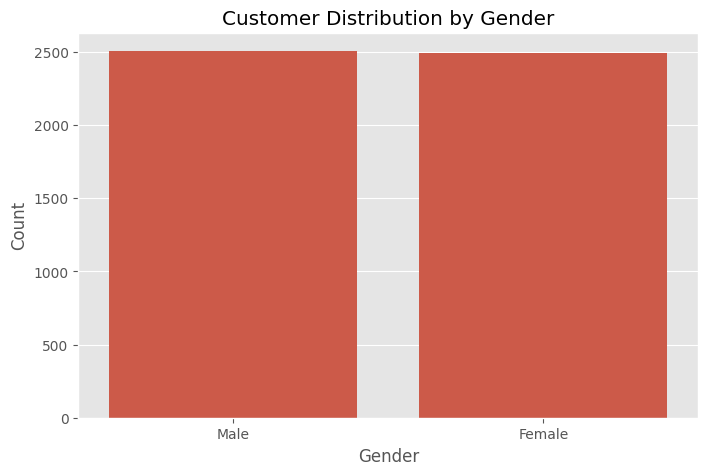

In [104]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=customers,
    x='gender'
)

plt.title('Customer Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')

plt.show()

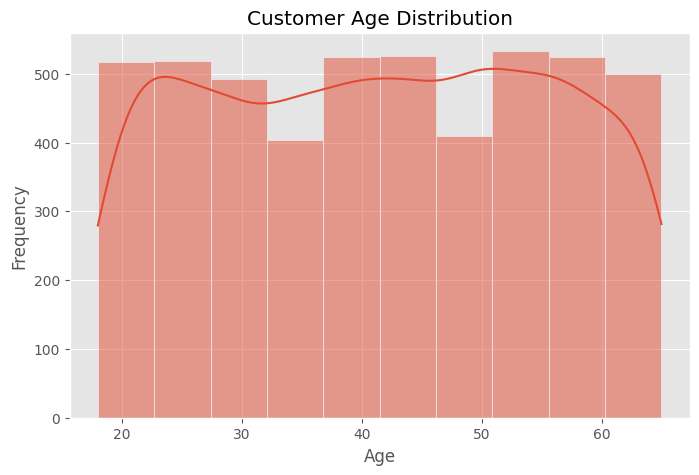

In [105]:
plt.figure(figsize=(8,5))

sns.histplot(
    customers['age'],
    bins=10,
    kde=True
)

plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

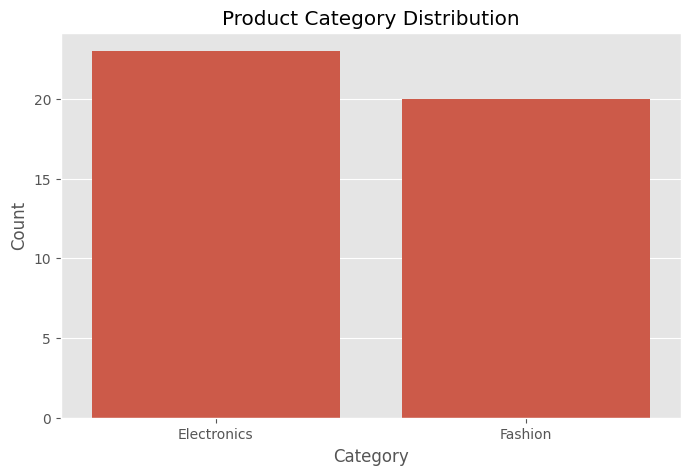

In [106]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=products,
    x='category'
)

plt.title('Product Category Distribution')
plt.xlabel('Category')
plt.ylabel('Count')

plt.show()

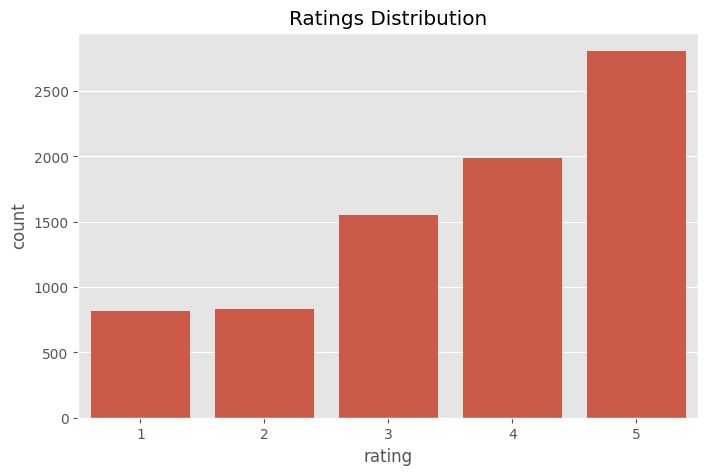

In [107]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=reviews,
    x='rating'
)

plt.title('Ratings Distribution')

plt.show()

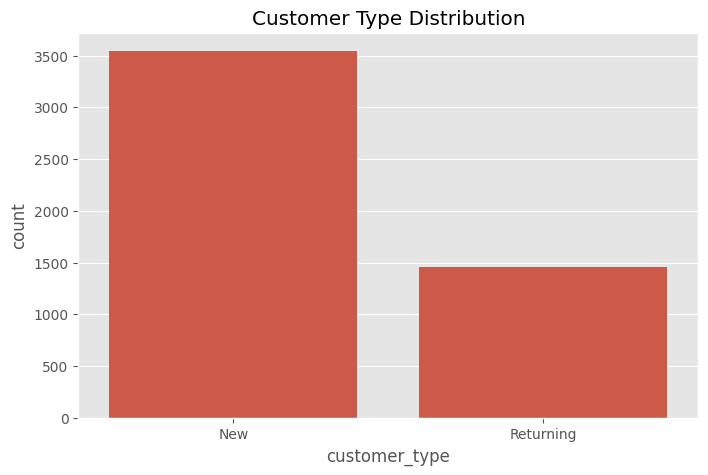

In [108]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=customers,
    x='customer_type'
)

plt.title('Customer Type Distribution')

plt.show()

# Data Merging
Combining orders, customers, and products datasets to create a master analytical dataset.

In [109]:
master_df = (
    orders
    .merge(customers, on='customer_id', how='left')
    .merge(products, on='product_id', how='left')
)

master_df.head()

,order_id,customer_id,product_id,quantity,discount_pct,final_amount,payment_method,order_date,customer_name,gender,age,city,join_date,customer_type,product_name,brand,category,base_price
0,O00001,C02766,P0028,2,20,7154.06,Cash on Delivery,2025-03-31,Watika Tiwari,Female,37.0,Delhi,2023-08-30,Returning,Ultraboost Shoes,Adidas,Fashion,4471.29
1,O00002,C00541,P0019,1,0,22443.05,Cash on Delivery,2026-01-29,Matthew Subramaniam,Male,59.0,Bangalore,2025-10-15,New,JBL PartyBox,JBL,Electronics,22443.05
2,O00003,C02285,P0010,1,10,56874.64,Cash on Delivery,2025-02-20,Pushti Dhar,Male,40.0,Hyderabad,2024-10-06,Returning,Galaxy Watch 6,Samsung,Electronics,63194.04
3,O00004,C03714,P0004,4,20,112223.30,Debit Card,2024-09-19,Wazir Soman,Female,44.0,Delhi,2024-06-03,New,MacBook Air,Apple,Electronics,35069.78
4,O00005,C01590,P0012,5,15,403441.83,Cash on Delivery,2026-02-02,Omaja Chakrabarti,Male,32.0,Kolkata,2026-02-15,New,WH-1000XM5,Sony,Electronics,94927.49


In [110]:
master_df['year'] = master_df['order_date'].dt.year

master_df['month'] = master_df['order_date'].dt.month_name()

master_df['month_year'] = master_df['order_date'].dt.to_period('M')

In [111]:
master_df.shape

(20000, 21)

In [112]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        20000 non-null  object        
 1   customer_id     20000 non-null  object        
 2   product_id      20000 non-null  object        
 3   quantity        20000 non-null  int64         
 4   discount_pct    20000 non-null  int64         
 5   final_amount    20000 non-null  float64       
 6   payment_method  20000 non-null  object        
 7   order_date      20000 non-null  datetime64[ns]
 8   customer_name   20000 non-null  object        
 9   gender          20000 non-null  object        
 10  age             19798 non-null  float64       
 11  city            19614 non-null  object        
 12  join_date       20000 non-null  datetime64[ns]
 13  customer_type   20000 non-null  object        
 14  product_name    20000 non-null  object        
 15  br

# Revenue Analysis
Analyzing overall sales performance and revenue trends.

In [113]:
total_revenue = master_df['final_amount'].sum()

print(f"Total Revenue: ₹{total_revenue:,.2f}")

Total Revenue: ₹1,242,785,248.19


In [114]:
total_revenue = master_df['final_amount'].sum()

print(f"Total Revenue: ₹{total_revenue:,.2f}")

Total Revenue: ₹1,242,785,248.19


In [115]:
total_customers = master_df['customer_id'].nunique()

print(f"Total Customers: {total_customers:,}")

Total Customers: 4,914


In [116]:
aov = master_df['final_amount'].mean()

print(f"Average Order Value: ₹{aov:,.2f}")

Average Order Value: ₹62,139.26


In [117]:
monthly_revenue = (
    master_df
    .groupby('month_year')['final_amount']
    .sum()
    .reset_index()
)

monthly_revenue

,month_year,final_amount
0,2024-06,31780185.31
1,2024-07,54969830.45
2,2024-08,53483871.32
3,2024-09,46646575.81
4,2024-10,52160569.33
5,2024-11,46230837.55
6,2024-12,55405789.71
7,2025-01,50416667.06
8,2025-02,46452943.10
9,2025-03,49379985.88


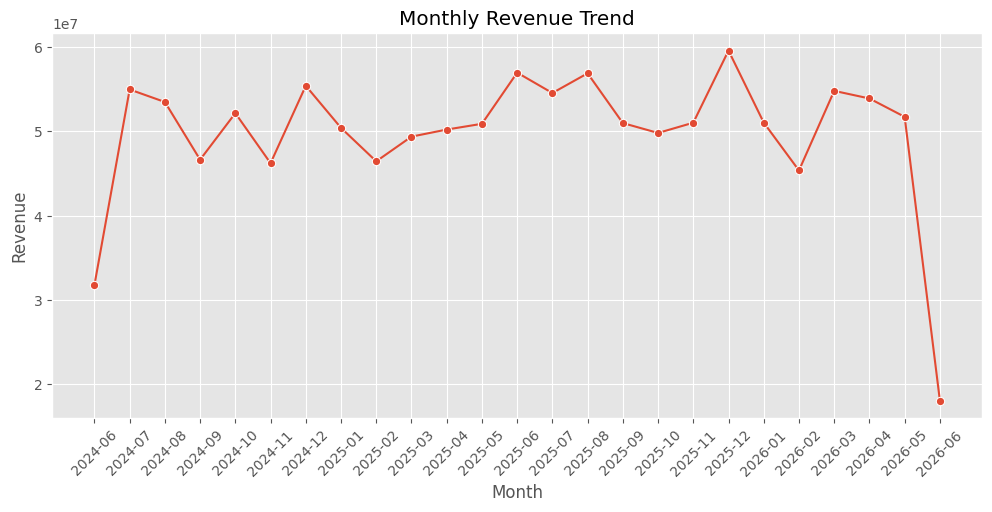

In [119]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=monthly_revenue,
    x=monthly_revenue['month_year'].astype(str),
    y='final_amount',
    marker='o'
)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.xticks(rotation=45)

plt.show()

In [120]:
category_revenue = (
    master_df
    .groupby('category')['final_amount']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

category_revenue

,category,final_amount
0,Electronics,1.111685e+09
1,Fashion,1.311002e+08


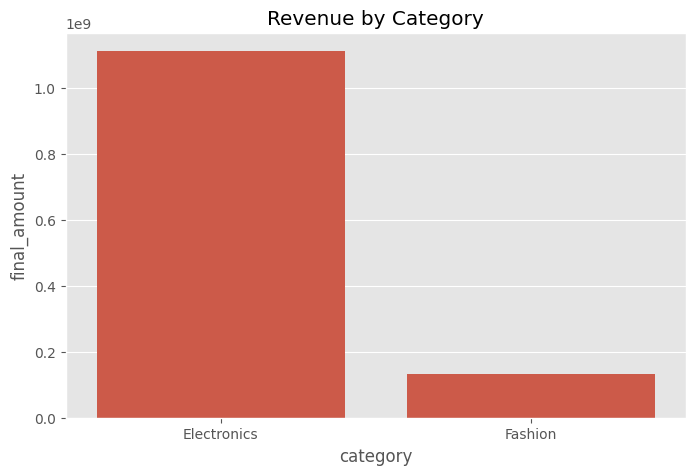

In [121]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=category_revenue,
    x='category',
    y='final_amount'
)

plt.title('Revenue by Category')

plt.show()

# Customer Analysis
Analyzing customer behavior, demographics, and revenue contribution.

In [122]:
customer_type_revenue = (
    master_df
    .groupby('customer_type')['final_amount']
    .sum()
    .reset_index()
)

customer_type_revenue

,customer_type,final_amount
0,New,8.728834e+08
1,Returning,3.699018e+08


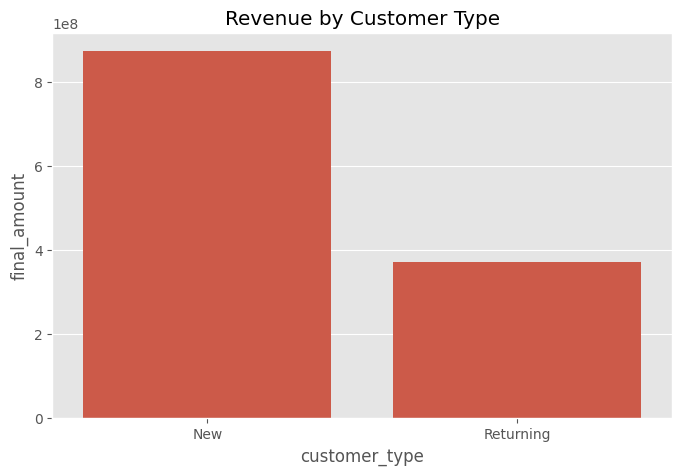

In [123]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=customer_type_revenue,
    x='customer_type',
    y='final_amount'
)

plt.title('Revenue by Customer Type')

plt.show()

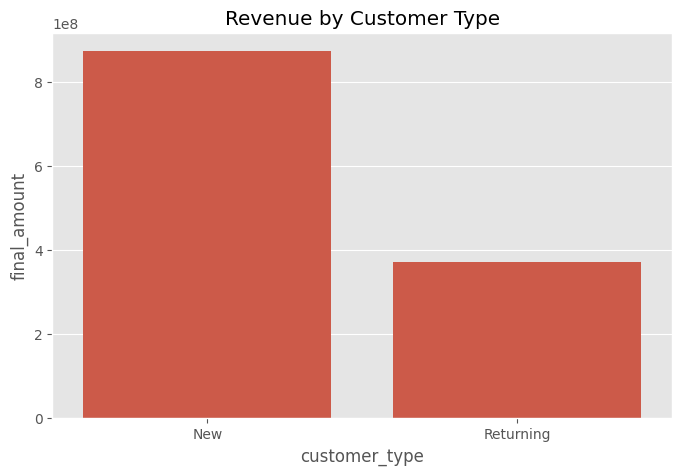

In [124]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=customer_type_revenue,
    x='customer_type',
    y='final_amount'
)

plt.title('Revenue by Customer Type')

plt.show()

In [125]:
master_df['age_group'] = pd.cut(
    master_df['age'],
    bins=[18,25,35,45,55,100],
    labels=['18-24','25-34','35-44','45-54','55+']
)

In [126]:
age_revenue = (
    master_df
    .groupby('age_group')['final_amount']
    .sum()
    .reset_index()
)

age_revenue

/tmp/ipykernel_3279/892288929.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('age_group')['final_amount']


,age_group,final_amount
0,18-24,1.866903e+08
1,25-34,2.472271e+08
2,35-44,2.628802e+08
3,45-54,2.648800e+08
4,55+,2.463128e+08


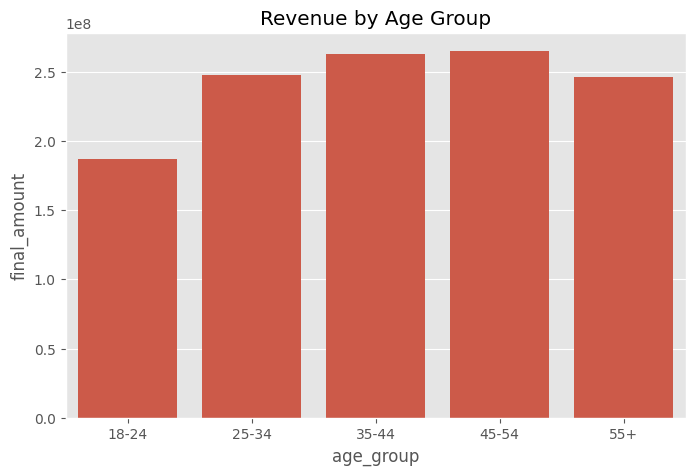

In [127]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=age_revenue,
    x='age_group',
    y='final_amount'
)

plt.title('Revenue by Age Group')

plt.show()

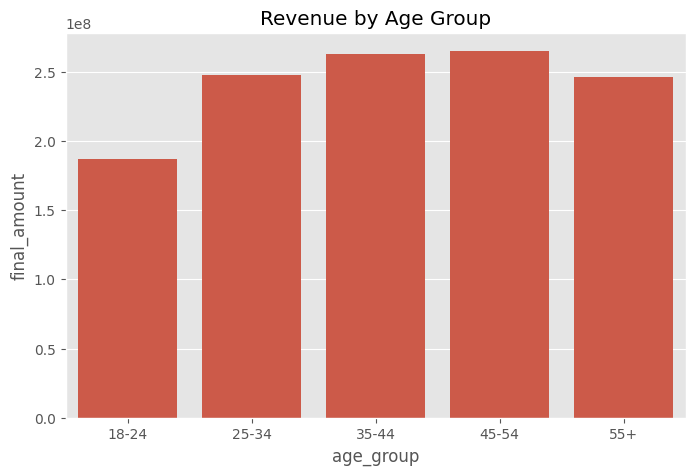

In [128]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=age_revenue,
    x='age_group',
    y='final_amount'
)

plt.title('Revenue by Age Group')

plt.show()

In [129]:
city_revenue = (
    master_df
    .groupby('city')['final_amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

city_revenue

,city,final_amount
0,Bangalore,1.532762e+08
1,Kolkata,1.530566e+08
2,Pune,1.522308e+08
3,Ahmedabad,1.507714e+08
4,Chennai,1.448857e+08
5,Mumbai,1.419937e+08
6,Delhi,1.404663e+08
7,Hyderabad,1.382009e+08
8,mumbai,2.511268e+07
9,MUMBAI,2.028175e+07


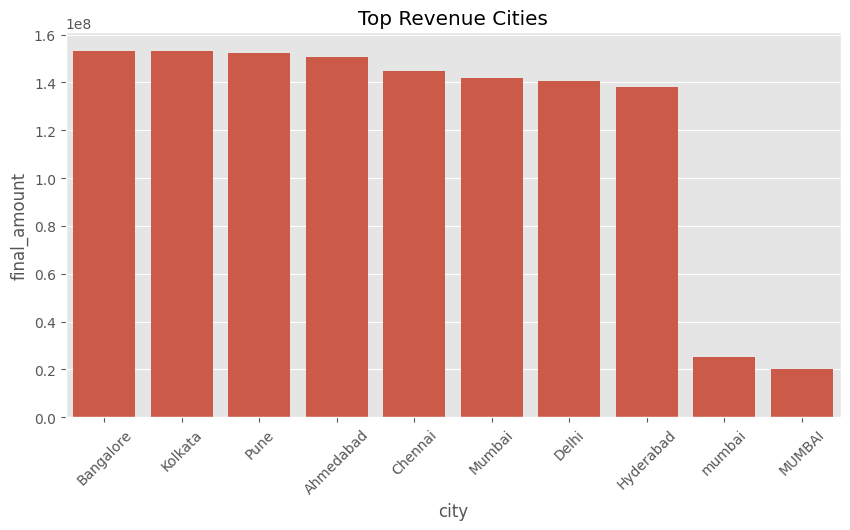

In [130]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=city_revenue,
    x='city',
    y='final_amount'
)

plt.title('Top Revenue Cities')

plt.xticks(rotation=45)

plt.show()

# Product Performance Analysis
Analyzing product, category, and brand performance.

In [131]:
product_revenue = (
    master_df
    .groupby('product_name')['final_amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

product_revenue

,product_name,final_amount
0,AirPods Pro,1.314218e+08
1,Bravia TV,1.193905e+08
2,WH-1000XM5,1.124226e+08
3,Galaxy Watch 6,8.215541e+07
4,Xperia Smartphone,7.616641e+07
5,iPhone 15 Pro,7.301976e+07
6,Sony Soundbar,5.373838e+07
7,Samsung Smart TV,5.371637e+07
8,Galaxy S24 Ultra,5.208781e+07
9,MacBook Air,4.325156e+07


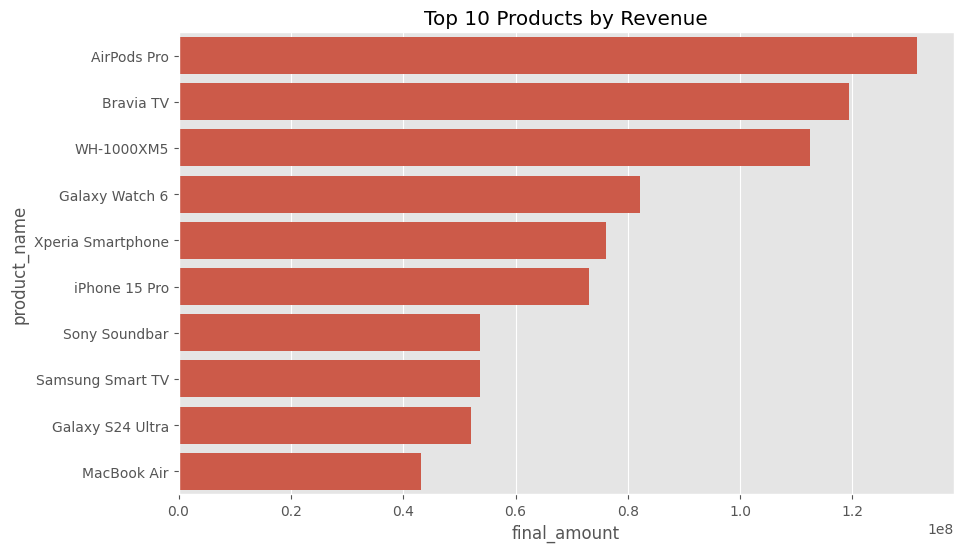

In [132]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=product_revenue,
    x='final_amount',
    y='product_name'
)

plt.title('Top 10 Products by Revenue')

plt.show()

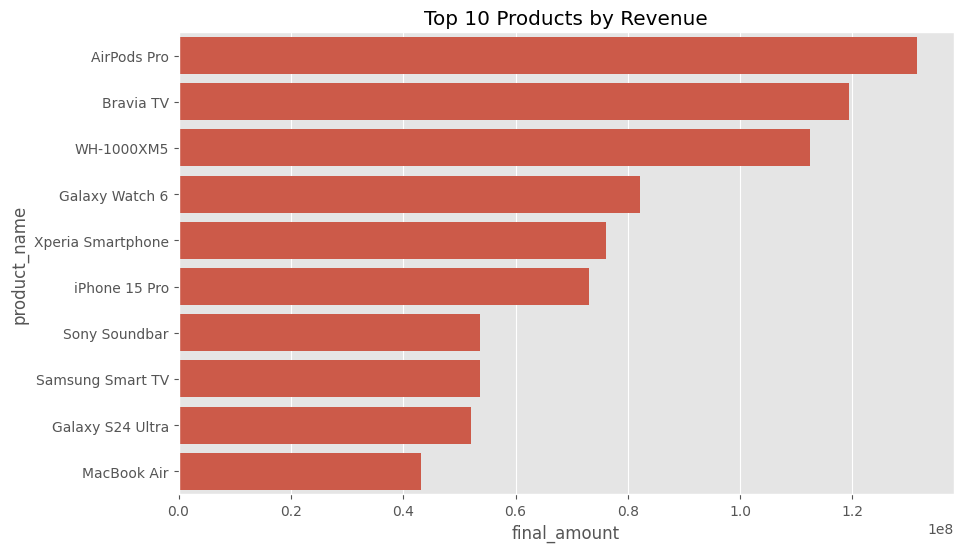

In [133]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=product_revenue,
    x='final_amount',
    y='product_name'
)

plt.title('Top 10 Products by Revenue')

plt.show()

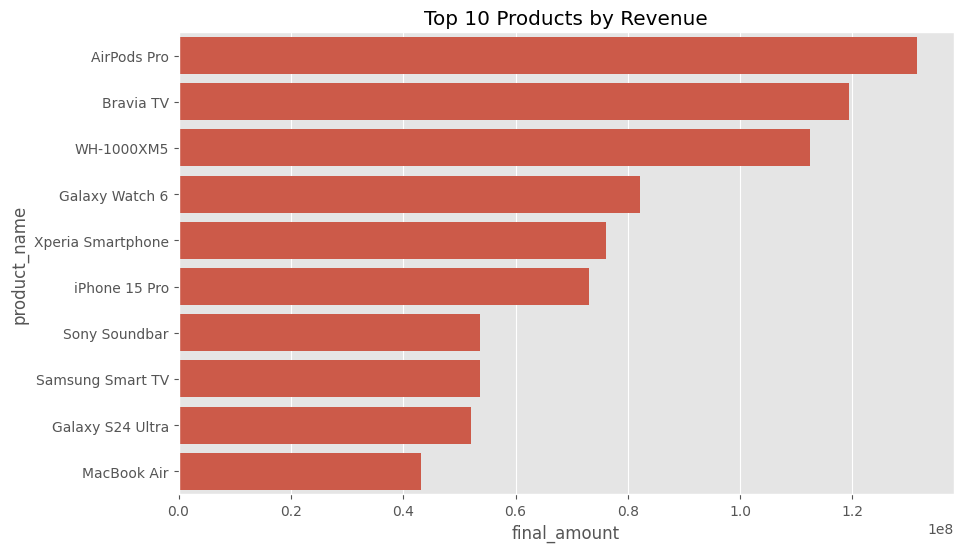

In [134]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=product_revenue,
    x='final_amount',
    y='product_name'
)

plt.title('Top 10 Products by Revenue')

plt.show()

In [135]:
brand_revenue = (
    master_df
    .groupby('brand')['final_amount']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

brand_revenue

,brand,final_amount
0,Apple,3.728133e+08
1,Sony,3.617179e+08
2,Samsung,2.476645e+08
3,JBL,9.916209e+07
4,Adidas,3.452436e+07
5,Boat,3.032724e+07
6,Puma,3.011427e+07
7,Levis,2.987620e+07
8,Nike,2.095729e+07
9,H&M,1.562810e+07


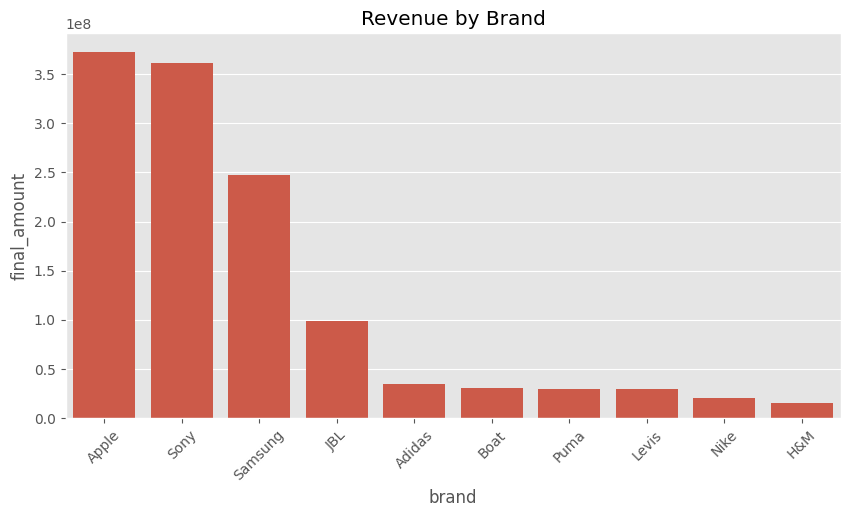

In [136]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=brand_revenue,
    x='brand',
    y='final_amount'
)

plt.title('Revenue by Brand')

plt.xticks(rotation=45)

plt.show()

# Review Analysis
Analyzing customer ratings and sentiment.

In [137]:
review_df = (
    reviews
    .merge(products,on='product_id')
)

In [138]:
avg_rating = reviews['rating'].mean()

print(f"Average Rating: {avg_rating:.2f}")

Average Rating: 3.64


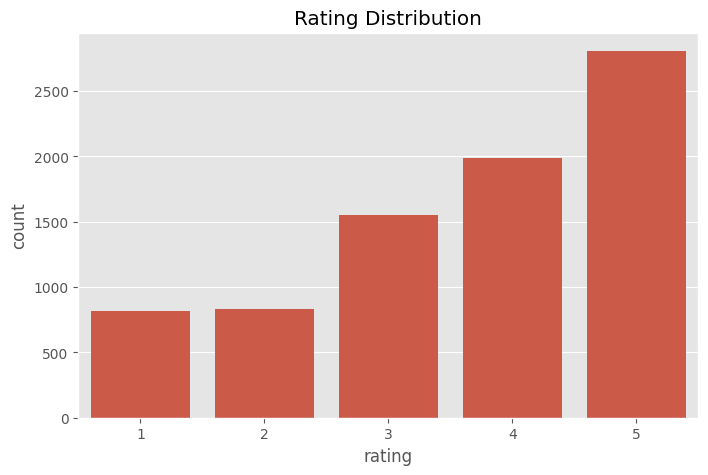

In [139]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=reviews,
    x='rating'
)

plt.title('Rating Distribution')

plt.show()

In [140]:
sentiment_dist = (
    reviews['sentiment_label']
    .value_counts()
    .reset_index()
)

sentiment_dist.columns = ['Sentiment','Count']

sentiment_dist

,Sentiment,Count
0,Positive,4792
1,Negative,1654
2,Neutral,1554


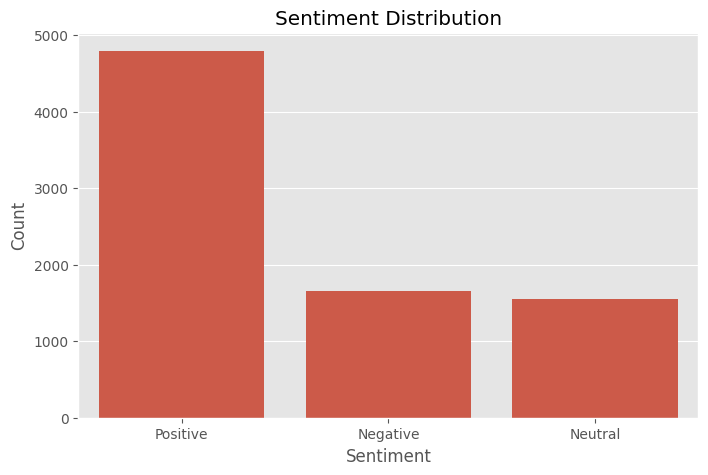

In [141]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=sentiment_dist,
    x='Sentiment',
    y='Count'
)

plt.title('Sentiment Distribution')

plt.show()

# Funnel Analysis
Analyzing customer journey through the sales funnel.

In [142]:
funnel_summary = (
    funnel
    .groupby('event_type')['customer_id']
    .nunique()
    .reset_index()
)

funnel_summary

,event_type,customer_id
0,Add To Cart,3906
1,Checkout,3144
2,Product View,4572
3,Purchase,3128
4,Visit,4888


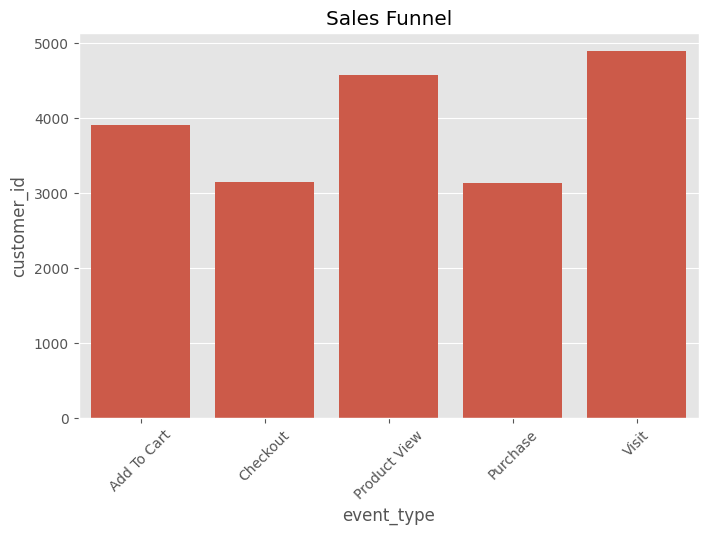

In [143]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=funnel_summary,
    x='event_type',
    y='customer_id'
)

plt.title('Sales Funnel')

plt.xticks(rotation=45)

plt.show()

# Key Business Insights

## Revenue Insights
- Electronics contributes the majority of total revenue.
- Apple and Sony are the highest-performing brands.
- Revenue remains stable across most months.

## Customer Insights
- New customers contribute most revenue.
- Mumbai is the highest revenue-generating city.
- Customers aged 55+ contribute the largest share of revenue.

## Product Insights
- AirPods Pro is the top revenue-generating product.
- Positive reviews account for the majority of customer feedback.
- Product ratings average around 3.6/5.

# Business Recommendations

### Increase Customer Retention
- Launch loyalty programs.
- Offer personalized discounts.
- Improve email remarketing.

### Expand Electronics Category
- Increase inventory.
- Create product bundles.
- Strengthen partnerships with Apple and Sony.

### Focus on High Revenue Cities
- Increase marketing in Mumbai and Bangalore.
- Run localized campaigns.

### Improve Customer Experience
- Address recurring negative reviews.
- Improve product quality and support.

# Conclusion

This project analyzed customer behavior, sales performance, product trends, reviews, and conversion funnel performance for ShopEasy.

The analysis identified key growth opportunities in customer retention, product optimization, and category expansion, providing actionable business recommendations supported by data.